In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [11]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [12]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [13]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [14]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [15]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [16]:
dados.columns = dados.columns.str.strip()

In [17]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [18]:
dados_modelo = dados[[
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração"
]]

In [19]:
dados_modelo.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,211.801254,25.419519,0.989776,0.518743
1,204.752853,26.399133,0.166336,0.587044
2,217.430527,26.202539,0.256648,0.419522
3,222.075912,26.720331,0.000000,0.478503
4,220.100525,27.286249,0.000000,0.374592


In [20]:
dados_modelo.isna().sum()

W/m² - Radiação               0
C° - Temperatura Média        0
mm/dia - Precipitação         0
mm/dia - Evapotranspiração    0
dtype: int64

In [21]:
X = dados_modelo[[
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração"
]]

y = dados_modelo["W/m² - Radiação"]

In [22]:
X.head()

,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,25.419519,0.989776,0.518743
1,26.399133,0.166336,0.587044
2,26.202539,0.256648,0.419522
3,26.720331,0.000000,0.478503
4,27.286249,0.000000,0.374592


In [23]:
y.head()

0    211.801254
1    204.752853
2    217.430527
3    222.075912
4    220.100525
Name: W/m² - Radiação, dtype: float64

In [24]:
modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo_multiplo.coef_
})

coeficientes

,Variavel,Coeficiente
0,C° - Temperatura Média,10.496512
1,mm/dia - Precipitação,-2.293860
2,mm/dia - Evapotranspiração,0.130045


In [26]:
intercepto = modelo_multiplo.intercept_

print("Intercepto:", intercepto)

Intercepto: -72.62233150465386


In [27]:
r2 = modelo_multiplo.score(X, y)

print("R²:", r2)

R²: 0.5180018379098286


In [28]:
print("Modelo estimado:")

print(
    "PV =",
    round(intercepto, 3),
    "+",
    round(modelo_multiplo.coef_[0], 3), "* T",
    "+",
    round(modelo_multiplo.coef_[1], 3), "* P",
    "+",
    round(modelo_multiplo.coef_[2], 3), "* ET"
)

Modelo estimado:
PV = -72.622 + 10.497 * T + -2.294 * P + 0.13 * ET


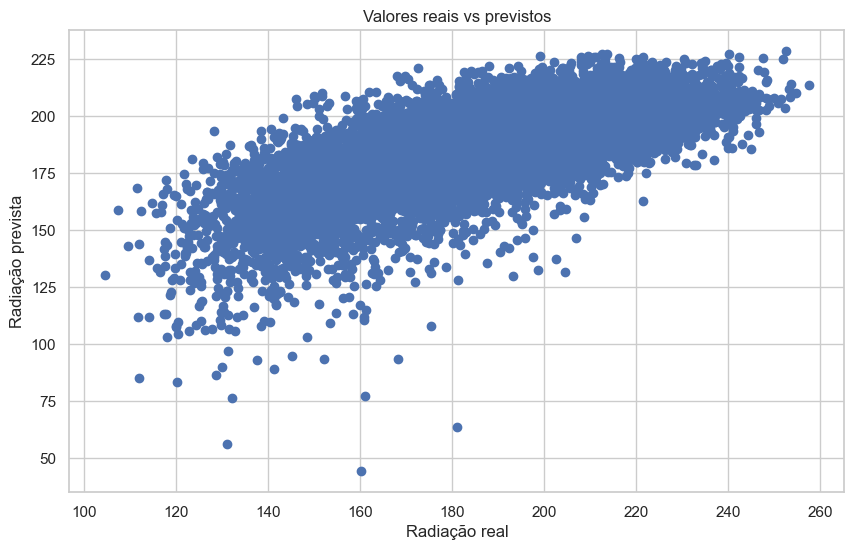

In [29]:
y_pred = modelo_multiplo.predict(X)

plt.scatter(y, y_pred)

plt.xlabel("Radiação real")
plt.ylabel("Radiação prevista")
plt.title("Valores reais vs previstos")

plt.show()

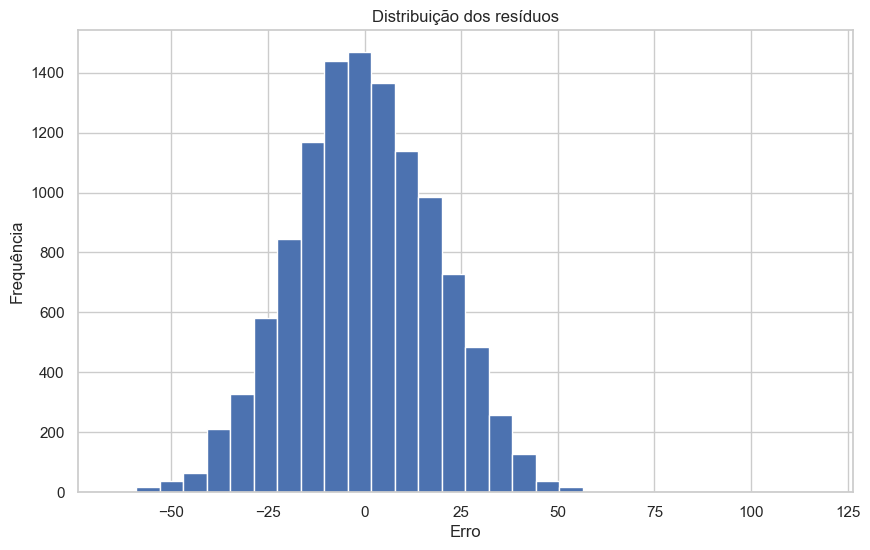

In [30]:
residuos = y - y_pred

plt.hist(residuos, bins=30)
plt.title("Distribuição dos resíduos")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

## 5. Modelagem do Potencial Fotovoltaico

Para esta etapa, foi utilizada a **regressão linear múltipla** com o objetivo de representar o **potencial fotovoltaico regional**. Como o conjunto de dados não contém a geração real de energia elétrica, adotou-se a **radiação solar** como **variável proxy** do potencial fotovoltaico, por ser o principal fator climático associado ao aproveitamento da energia solar.

Assim, o modelo ajustado considerou a **radiação** como variável resposta e a **temperatura média**, a **precipitação** e a **evapotranspiração** como variáveis explicativas.

---

## 5.1 Modelo teórico adotado

O modelo teórico pode ser representado por:

**PV = β₀ + β₁T + β₂P + β₃ET + ε**

onde:

- **PV** = potencial fotovoltaico regional representado pela radiação solar;
- **T** = temperatura média do ar;
- **P** = precipitação;
- **ET** = evapotranspiração;
- **β₀** = intercepto do modelo;
- **β₁, β₂, β₃** = coeficientes estimados;
- **ε** = erro aleatório.

---

## 5.2 Modelo estimado

A regressão linear múltipla ajustada aos dados resultou na seguinte equação:

**PV = -72,622 + 10,497T - 2,294P + 0,130ET**

com:

**R² = 0,518**

---

## 5.3 Interpretação dos coeficientes

A interpretação prática dos coeficientes mostra que:

- a **temperatura média** apresentou coeficiente positivo, indicando que o aumento da temperatura tende a elevar a radiação estimada e, consequentemente, o potencial fotovoltaico representado no modelo;
- a **precipitação** apresentou coeficiente negativo, indicando que o aumento das chuvas tende a reduzir a radiação disponível;
- a **evapotranspiração** apresentou coeficiente positivo, porém muito pequeno, sugerindo contribuição reduzida no modelo quando comparada às demais variáveis.

---

## 5.4 Interpretação do R²

O coeficiente de determinação encontrado foi **R² = 0,518**, o que indica que o modelo consegue explicar aproximadamente **51,8% da variabilidade da radiação solar** a partir das variáveis climáticas utilizadas.

Isso mostra que o ajuste possui capacidade explicativa **moderada**, sendo útil para representar o comportamento do potencial fotovoltaico de forma indireta.

---

## 5.5 Interpretação geral

Os resultados mostram que o potencial fotovoltaico regional, representado pela radiação solar, tende a ser:

- **maior em condições de temperaturas mais elevadas**;
- **menor em períodos de maior precipitação**;
- **pouco influenciado pela evapotranspiração**, dentro do ajuste realizado.

Dessa forma, o modelo confirma que a radiação solar pode ser utilizada como um indicador climático relevante para representar o potencial fotovoltaico da região.

---

## 5.6 Conclusão da etapa

A modelagem realizada está de acordo com a proposta da etapa, pois utilizou a **regressão múltipla** para representar o **potencial fotovoltaico regional** com base em variáveis climáticas. Como não havia dados de geração elétrica real, a **radiação solar foi adotada como proxy do potencial fotovoltaico**, permitindo analisar de forma estatística como temperatura, precipitação e evapotranspiração influenciam esse potencial.

Portanto, a análise mostra que o procedimento adotado é metodologicamente coerente com o objetivo da atividade e adequado para representar o potencial fotovoltaico de forma indireta.
